<h5>Step 1: Data Preparation</h5>

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# ── 1. Load files ──────────────────────────────────────────────
print("Loading files...")

ml = pd.read_csv("Outputs/feature_engineering/ml_dataset_enhanced.csv")
ml["earnings_date"] = pd.to_datetime(ml["earnings_date"])

prices = pd.read_csv("Data/stock_prices_updated.csv")
prices["Date"] = pd.to_datetime(prices["Date"])
prices = prices.sort_values(["ticker", "Date"]).reset_index(drop=True)

# rename sp500 columns correctly before converting dates
sp500 = pd.read_csv("Data/sp500_prices.csv")

if "Date" not in sp500.columns:
    sp500 = sp500.rename(columns={
        sp500.columns[0]: "Date",
        sp500.columns[1]: "sp500_close"
    })
else:
    close_col = [c for c in sp500.columns if c != "Date"][0]
    sp500 = sp500.rename(columns={close_col: "sp500_close"})

sp500["Date"] = pd.to_datetime(sp500["Date"])
sp500 = sp500.sort_values("Date").reset_index(drop=True)

print(f"      ml_dataset:     {len(ml):,} earnings events · {ml['ticker'].nunique():,} tickers")
print(f"      stock prices:   {len(prices):,} daily rows · {prices['ticker'].nunique():,} tickers")
print(f"      S&P 500 prices: {len(sp500):,} daily rows")
print(f"      Date range:     {prices['Date'].min().date()} → {prices['Date'].max().date()}")

Loading files...
      ml_dataset:     13,803 earnings events · 2,078 tickers
      stock prices:   3,559,854 daily rows · 2,194 tickers
      S&P 500 prices: 1,760 daily rows
      Date range:     2017-01-03 → 2023-12-29


In [2]:
# ── 2. Compute daily returns ───────────────────────────────────
print("Computing daily returns...")

prices["stock_return"] = prices.groupby("ticker")["close"].pct_change()
sp500["market_return"] = sp500["sp500_close"].pct_change()

print(f"      Stock return nulls (first row per ticker): {prices['stock_return'].isna().sum():,}")
print(f"      Market return nulls: {sp500['market_return'].isna().sum():,}")

Computing daily returns...
      Stock return nulls (first row per ticker): 2,194
      Market return nulls: 1


In [3]:
# ── 3. Merge market returns into prices ───────────────────────
print("Merging market returns into price data...")

prices = prices.merge(sp500[["Date", "market_return"]], on="Date", how="left")

missing_market = prices["market_return"].isna().sum()
print(f"      Rows missing market return (non-trading days): {missing_market:,}")
print(f"      Combined price frame: {prices.shape}")

Merging market returns into price data...
      Rows missing market return (non-trading days): 1,780
      Combined price frame: (3559854, 5)


In [10]:
# ── 4. Build event windows ────────────────────────────────────
print("Building event windows for each earnings call...")
print("      Estimation window: [-120, -10] trading days before earnings")
print("      Event window:      [-1,  +10]  trading days around earnings")

# ssing union of all trading dates as the calendar; a per-ticker trading calendar
# would be more rigorous for IPO, delisted, or suspended stocks, but is left as
# a future improvement. Coverage filter in Step 5 handles edge cases automatically.
all_dates = pd.DatetimeIndex(sorted(prices["Date"].unique()))

def get_trading_date_offset(ref_date, offset, date_index):
    """Return the trading date that is `offset` days from ref_date."""
    pos = date_index.searchsorted(ref_date)
    target_pos = pos + offset
    if target_pos < 0 or target_pos >= len(date_index):
        return pd.NaT
    return date_index[target_pos]

events = []
skipped = 0

for idx, row in ml.iterrows():
    ticker       = row["ticker"]
    edate        = row["earnings_date"]
    net_sent     = row["net_sentiment"]
    sector       = row["sector"]
    beta_given   = row["beta"]

    # find estimation window
    est_start = get_trading_date_offset(edate, -120, all_dates)
    est_end   = get_trading_date_offset(edate, -10,  all_dates)

    # find event window
    evt_start = get_trading_date_offset(edate, -1,   all_dates)
    evt_end   = get_trading_date_offset(edate, +10,  all_dates)

    if pd.isna(est_start) or pd.isna(evt_end):
        skipped += 1
        continue

    events.append({
        "ticker"            : ticker,
        "earnings_date"     : edate,
        "net_sentiment"     : net_sent,
        "sector"            : sector,
        "beta_given"        : beta_given,
        "est_start"         : est_start,
        "est_end"           : est_end,
        "evt_start"         : evt_start,
        "evt_end"           : evt_end,
        "mgmt_sentiment"    : row.get("mgmt_sentiment", np.nan),
        "qa_sentiment"      : row.get("qa_sentiment", np.nan),
        "sentiment_surprise": row.get("sentiment_surprise", np.nan),
        "confidence_score"  : row.get("confidence_score", np.nan),
        "risk_score"        : row.get("risk_score", np.nan),
    })

events_df = pd.DataFrame(events)
print(f"\n      Events built:   {len(events_df):,}")
print(f"      Events skipped: {skipped} (insufficient price history at edges)")

Building event windows for each earnings call...
      Estimation window: [-120, -10] trading days before earnings
      Event window:      [-1,  +10]  trading days around earnings

      Events built:   13,803
      Events skipped: 0 (insufficient price history at edges)


In [12]:
print("Validating price coverage per event...")

price_groups = {
    ticker: grp[["Date"]].sort_values("Date").reset_index(drop=True)
    for ticker, grp in prices.groupby("ticker")
}

coverage = []

for _, evt in events_df.iterrows():
    ticker_prices = price_groups.get(evt["ticker"])

    if ticker_prices is None:
        est_days = 0
        evt_days = 0
    else:
        dates = ticker_prices["Date"]

        est_days = dates.between(evt["est_start"], evt["est_end"]).sum()
        evt_days = dates.between(evt["evt_start"], evt["evt_end"]).sum()

    coverage.append({
        "ticker": evt["ticker"],
        "earnings_date": evt["earnings_date"],
        "est_days": est_days,
        "evt_days": evt_days,
        "sufficient": est_days >= 60 and evt_days >= 8
    })

coverage_df = pd.DataFrame(coverage)

sufficient = coverage_df["sufficient"].sum()
insufficient = (~coverage_df["sufficient"]).sum()

print(f"      Events with sufficient data:   {sufficient:,}")
print(f"      Events with insufficient data: {insufficient:,}")
print(f"      Avg estimation window days:    {coverage_df['est_days'].mean():.1f}")
print(f"      Avg event window days:         {coverage_df['evt_days'].mean():.1f}")

valid_events = events_df[coverage_df["sufficient"].values].reset_index(drop=True)

print(f"\n      Final event count for analysis: {len(valid_events):,}")

Validating price coverage per event...
      Events with sufficient data:   13,760
      Events with insufficient data: 43
      Avg estimation window days:    110.6
      Avg event window days:         12.0

      Final event count for analysis: 13,760


In [13]:
# ── 6. Save prepared data ─────────────────────────────────────
print("Saving prepared data...")

import os
os.makedirs("Outputs/event_study", exist_ok=True)

valid_events.to_csv("Outputs/event_study/events_prepared.csv", index=False)
prices.to_csv("Outputs/event_study/prices_with_returns.csv", index=False)

print("      Saved → Outputs/event_study/events_prepared.csv")
print("      Saved → Outputs/event_study/prices_with_returns.csv")

Saving prepared data...
      Saved → Outputs/event_study/events_prepared.csv
      Saved → Outputs/event_study/prices_with_returns.csv


In [14]:
print("=" * 60)
print("STEP 1 SUMMARY")
print("=" * 60)
print(f"  Total earnings events:    {len(ml):,}")
print(f"  Valid events for study:   {len(valid_events):,}")
print(f"  Tickers covered:          {valid_events['ticker'].nunique():,}")
print(f"  Date range:               {valid_events['earnings_date'].min().date()} → "
      f"{valid_events['earnings_date'].max().date()}")
print(f"  Estimation window:        120 → 10 trading days pre-earnings")
print(f"  Event window:             1 day pre → 10 days post earnings")
print("=" * 60)

STEP 1 SUMMARY
  Total earnings events:    13,803
  Valid events for study:   13,760
  Tickers covered:          2,078
  Date range:               2017-10-01 → 2023-02-23
  Estimation window:        120 → 10 trading days pre-earnings
  Event window:             1 day pre → 10 days post earnings


<h5>Step 2: CAPM Expected Return Estimation</h5>

- OLS fits `R_stock = α + β × R_market` using only the estimation window data, never touching the event window
- α captures the stock's average excess return over the market
- β captures the stock's sensitivity to market moves
- R² distribution tells how well the market explains each stock's returns during the estimation window

In [18]:
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")

# ensure market_return is in prices — re-merge if kernel was restarted
if "market_return" not in prices.columns:
    print("market_return not found in prices — re-merging S&P 500...")
    prices = prices.merge(sp500[["Date", "market_return"]], on="Date", how="left")
    nulls = prices['market_return'].isna().sum()
    print(f"market_return merged — {nulls:,} nulls")
    
# ── 1. pre-index prices for fast lookup ──────────────────────────
print("\nPre-indexing price data by ticker...")
price_groups = {
    ticker: grp[["Date", "stock_return", "market_return"]]
             .sort_values("Date")
             .reset_index(drop=True)
    for ticker, grp in prices.groupby("ticker")
}
print(f"      {len(price_groups):,} ticker groups indexed")


Pre-indexing price data by ticker...
      2,194 ticker groups indexed


In [19]:
# ── 2. fit CAPM per event ─────────────────────────────────────────
print("Fitting CAPM for each event...")

capm_results = []
skipped      = 0

for i, evt in valid_events.iterrows():
    ticker      = evt["ticker"]
    ticker_data = price_groups.get(ticker)

    if ticker_data is None:
        skipped += 1
        continue

    # slice estimation window
    est_data = ticker_data[
        (ticker_data["Date"] >= evt["est_start"]) &
        (ticker_data["Date"] <= evt["est_end"])
    ].dropna(subset=["stock_return", "market_return"])

    if len(est_data) < 60:
        # skil if not enough data for reliable OLS
        skipped += 1
        continue

    X = est_data["market_return"].values.reshape(-1, 1)
    y = est_data["stock_return"].values

    model = LinearRegression().fit(X, y)

    alpha   = model.intercept_
    beta    = model.coef_[0]
    r2      = model.score(X, y)
    n_obs   = len(est_data)

    capm_results.append({
        "ticker"            : ticker,
        "earnings_date"     : evt["earnings_date"],
        "net_sentiment"     : evt["net_sentiment"],
        "mgmt_sentiment"    : evt["mgmt_sentiment"],
        "qa_sentiment"      : evt["qa_sentiment"],
        "sentiment_surprise": evt["sentiment_surprise"],
        "confidence_score"  : evt["confidence_score"],
        "risk_score"        : evt["risk_score"],
        "sector"            : evt["sector"],
        "alpha"             : alpha,
        "beta_capm"         : beta,
        "beta_given"        : evt["beta_given"],
        "r2"                : r2,
        "n_est_obs"         : n_obs,
        "est_start"         : evt["est_start"],
        "est_end"           : evt["est_end"],
        "evt_start"         : evt["evt_start"],
        "evt_end"           : evt["evt_end"],
    })

    if (len(capm_results) % 1000) == 0:
        print(f"      Processed {len(capm_results):,} / {len(valid_events):,} events...")

capm_df = pd.DataFrame(capm_results)
print(f"\n      CAPM fits completed: {len(capm_df):,}")
print(f"      Events skipped:      {skipped}")

Fitting CAPM for each event...
      Processed 1,000 / 13,760 events...
      Processed 2,000 / 13,760 events...
      Processed 3,000 / 13,760 events...
      Processed 4,000 / 13,760 events...
      Processed 5,000 / 13,760 events...
      Processed 6,000 / 13,760 events...
      Processed 7,000 / 13,760 events...
      Processed 8,000 / 13,760 events...
      Processed 9,000 / 13,760 events...
      Processed 10,000 / 13,760 events...
      Processed 11,000 / 13,760 events...
      Processed 12,000 / 13,760 events...
      Processed 13,000 / 13,760 events...

      CAPM fits completed: 13,756
      Events skipped:      4


In [20]:
# ── 3. summary stats ──────────────────────────────────────────────
print("CAPM estimation summary...")
print(f"\n      {'Metric':<25} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print(f"      {'------':<25} {'----':>10} {'----':>10} {'---':>10} {'---':>10}")

for col, label in [
    ("alpha",    "Alpha (intercept)"),
    ("beta_capm","Beta (CAPM fitted)"),
    ("beta_given","Beta (from dataset)"),
    ("r2",       "R² (fit quality)"),
    ("n_est_obs","Estimation obs"),
]:
    s = capm_df[col]
    print(f"      {label:<25} {s.mean():>10.4f} {s.std():>10.4f} "
          f"{s.min():>10.4f} {s.max():>10.4f}")

# beta comparison
beta_corr = capm_df["beta_capm"].corr(capm_df["beta_given"])
print(f"\n      Correlation: CAPM beta vs dataset beta = {beta_corr:.4f}")
print(f"      (higher correlation suggests CAPM estimation is broadly consistent)")

# R² distribution
r2_bins = [0, 0.1, 0.2, 0.3, 0.5, 1.0]
r2_labels = ["0–0.1", "0.1–0.2", "0.2–0.3", "0.3–0.5", "0.5+"]
r2_counts = pd.cut(capm_df["r2"], bins=r2_bins, labels=r2_labels).value_counts().sort_index()
print(f"\n      R² distribution:")
for label, count in r2_counts.items():
    pct = count / len(capm_df) * 100
    print(f"        {label:<10} {count:>6,} events  ({pct:.1f}%)")

# save
capm_df.to_csv("Outputs/event_study/capm_estimates.csv", index=False)
print(f"\n      Saved → Outputs/event_study/capm_estimates.csv")

CAPM estimation summary...

      Metric                          Mean        Std        Min        Max
      ------                          ----       ----        ---        ---
      Alpha (intercept)             0.0001     0.0031    -0.0182     0.0621
      Beta (CAPM fitted)            1.1265     0.5535   -10.4873     4.1384
      Beta (from dataset)           1.0374     0.5686    -1.5820     5.7460
      R² (fit quality)              0.2378     0.1655     0.0000     0.8945
      Estimation obs              110.8130     2.4923    61.0000   111.0000

      Correlation: CAPM beta vs dataset beta = 0.3893
      (higher correlation suggests CAPM estimation is broadly consistent)

      R² distribution:
        0–0.1       3,068 events  (22.3%)
        0.1–0.2     3,623 events  (26.3%)
        0.2–0.3     2,868 events  (20.8%)
        0.3–0.5     3,031 events  (22.0%)
        0.5+        1,166 events  (8.5%)

      Saved → Outputs/event_study/capm_estimates.csv


In [21]:
print("=" * 60)
print("STEP 2 SUMMARY")
print("=" * 60)
print(f"  Events with CAPM estimates: {len(capm_df):,}")
print(f"  Avg beta (CAPM fitted):     {capm_df['beta_capm'].mean():.4f}")
print(f"  Avg R²:                     {capm_df['r2'].mean():.4f}")
print(f"  Beta vs dataset corr:       {beta_corr:.4f}")
print("=" * 60)

STEP 2 SUMMARY
  Events with CAPM estimates: 13,756
  Avg beta (CAPM fitted):     1.1265
  Avg R²:                     0.2378
  Beta vs dataset corr:       0.3893


**Alpha**
- Mean alpha = 0.0001 (essentially zero)
- Consistent with CAPM theory - no systematic mispricing in estimation window (healthy sign)

**Beta**
- Mean CAPM-fitted beta = 1.127 — slightly above 1, expected for a dataset tilted toward growth and technology stocks
- Correlation between CAPM-fitted beta and dataset beta = 0.389 (moderate)
- Difference is expected — dataset beta uses a 5-year monthly window while CAPM beta uses a 110-day daily window (different frequencies)
- One outlier flagged: beta min = -10.49 — likely a thin-trading or data issue → will be clipped to [-3, 5] before computing AR in Step 3

**R² (model fit quality)**
- Mean R² = 0.238 — the market explains ~24% of individual stock return variance
- 22.3% of events have R² < 0.1 — common for small-cap and idiosyncratic stocks
- 8.5% of events have R² > 0.5 — large-cap stocks well-explained by market


<h5>Step 3: Abnormal Return Computation</h5>

- AR  = actual return − (alpha + beta × market return)
- CAR = cumulative AR over event windows
- Windows: [0], [+1], [0,+1], [+1,+3], [+1,+5], [+1,+10]

In [23]:
# ── 1. clip extreme betas ─────────────────────────────────────────
print("Clipping extreme betas...")
before_clip = capm_df["beta_capm"].describe()[["min", "max"]]
capm_df["beta_capm"] = capm_df["beta_capm"].clip(-3, 5)
after_clip  = capm_df["beta_capm"].describe()[["min", "max"]]
print(f"      Beta before clip: min={before_clip['min']:.4f}, max={before_clip['max']:.4f}")
print(f"      Beta after clip:  min={after_clip['min']:.4f},  max={after_clip['max']:.4f}")

Clipping extreme betas...
      Beta before clip: min=-10.4873, max=4.1384
      Beta after clip:  min=-3.0000,  max=4.1384


In [24]:
# ── 2. pre-index for fast lookup ──────────────────────────────────
print("Pre-indexing price data by ticker...")
price_groups_ar = {
    ticker: grp[["Date", "stock_return", "market_return"]]
             .sort_values("Date")
             .reset_index(drop=True)
    for ticker, grp in prices.groupby("ticker")
}
print(f"      {len(price_groups_ar):,} ticker groups indexed")

Pre-indexing price data by ticker...
      2,194 ticker groups indexed


In [25]:
# ── 3. compute AR and CAR per event ──────────────────────────────
print("Computing abnormal returns for each event...")

# AR_0, CAR_0_1: immediate reaction
# CAR_1_5, CAR_1_10: longer-term drift
# CAR_minus1_1: pre-announcement leakage
CAR_WINDOWS = {
    "AR_0"         : (0,   0),
    "CAR_0_1"      : (0,   1),
    "CAR_1_3"      : (1,   3),
    "CAR_1_5"      : (1,   5),
    "CAR_1_10"     : (1,  10),
    "CAR_minus1_1" : (-1,  1),
}

ar_results = []
skipped    = 0

for _, evt in capm_df.iterrows():
    ticker      = evt["ticker"]
    edate       = pd.Timestamp(evt["earnings_date"])
    alpha       = evt["alpha"]
    beta        = evt["beta_capm"]
    ticker_data = price_groups_ar.get(ticker)

    if ticker_data is None:
        skipped += 1
        continue

    # get event window data
    evt_data = ticker_data[
        (ticker_data["Date"] >= evt["evt_start"]) &
        (ticker_data["Date"] <= evt["evt_end"])
    ].dropna(subset=["stock_return", "market_return"]).copy()

    if len(evt_data) < 3:
        skipped += 1
        continue

    # compute expected return and AR for each day
    evt_data["expected_return"] = alpha + beta * evt_data["market_return"]
    evt_data["AR"]              = evt_data["stock_return"] - evt_data["expected_return"]

    # derive rel_day directly from evt_data dates (consistent after dropna)
    evt_data = evt_data.sort_values("Date").reset_index(drop=True)

    # find first trading date on or after earnings date
    event_trading_date = evt_data.loc[evt_data["Date"] >= edate, "Date"].min()

    if pd.isna(event_trading_date):
        skipped += 1
        continue

    event_pos = evt_data.index[evt_data["Date"] == event_trading_date][0]
    evt_data["rel_day"] = np.arange(len(evt_data)) - event_pos

    # compute CARs for each window
    row = {
        "ticker"            : ticker,
        "earnings_date"     : edate,
        "net_sentiment"     : evt["net_sentiment"],
        "mgmt_sentiment"    : evt["mgmt_sentiment"],
        "qa_sentiment"      : evt["qa_sentiment"],
        "sentiment_surprise": evt["sentiment_surprise"],
        "confidence_score"  : evt["confidence_score"],
        "risk_score"        : evt["risk_score"],
        "sector"            : evt["sector"],
        "alpha"             : alpha,
        "beta_capm"         : beta,
        "r2"                : evt["r2"],
        "n_est_obs"         : evt["n_est_obs"],
    }

    # AR on earnings date
    ar_day0 = evt_data[evt_data["rel_day"] == 0]["AR"]
    row["AR_day0"] = ar_day0.values[0] if len(ar_day0) > 0 else np.nan

    # CAR windows
    for window_name, (start, end) in CAR_WINDOWS.items():
        window_data = evt_data[
            (evt_data["rel_day"] >= start) &
            (evt_data["rel_day"] <= end)
        ]["AR"]
        row[window_name] = window_data.sum() if len(window_data) > 0 else np.nan

    # daily AR for event-time plot (day -1 to +10)
    for rel_day in range(-1, 11):
        day_ar = evt_data[evt_data["rel_day"] == rel_day]["AR"]
        row[f"AR_day_{rel_day}"] = day_ar.values[0] if len(day_ar) > 0 else np.nan

    ar_results.append(row)

    if (len(ar_results) % 2000) == 0:
        print(f"      Processed {len(ar_results):,} / {len(capm_df):,} events...")

ar_df = pd.DataFrame(ar_results)
print(f"\n      AR computation completed: {len(ar_df):,} events")
print(f"      Events skipped:           {skipped}")

Computing abnormal returns for each event...
      Processed 2,000 / 13,756 events...
      Processed 4,000 / 13,756 events...
      Processed 6,000 / 13,756 events...
      Processed 8,000 / 13,756 events...
      Processed 10,000 / 13,756 events...
      Processed 12,000 / 13,756 events...

      AR computation completed: 13,756 events
      Events skipped:           0


In [26]:
# ── 3. sentiment groups ───────────────────────────────────────────
print("Assigning sentiment groups...")

# primary split: positive vs negative
ar_df["sentiment_group"] = np.where(
    ar_df["net_sentiment"] > 0, "Positive", "Negative"
)

# quartile split (more robust, equal-sized groups)
ar_df["sentiment_quartile"] = pd.qcut(
    ar_df["net_sentiment"], q=4,
    labels=["Q1 (most negative)", "Q2", "Q3", "Q4 (most positive)"]
)

# sentiment surprise split
ar_df["surprise_group"] = np.where(
    ar_df["sentiment_surprise"] > 0,
    "Positive surprise", "Negative surprise"
)

pos_count = (ar_df["sentiment_group"] == "Positive").sum()
neg_count = (ar_df["sentiment_group"] == "Negative").sum()
q1_count  = (ar_df["sentiment_quartile"] == "Q1 (most negative)").sum()
q4_count  = (ar_df["sentiment_quartile"] == "Q4 (most positive)").sum()

print(f"      Positive sentiment:      {pos_count:,} events ({pos_count/len(ar_df)*100:.1f}%)")
print(f"      Negative sentiment:      {neg_count:,} events ({neg_count/len(ar_df)*100:.1f}%)")
print(f"      Q1 (most negative):      {q1_count:,} events ({q1_count/len(ar_df)*100:.1f}%)")
print(f"      Q4 (most positive):      {q4_count:,} events ({q4_count/len(ar_df)*100:.1f}%)")

# note if positive/negative split is imbalanced
if pos_count / len(ar_df) > 0.65 or neg_count / len(ar_df) > 0.65:
    print(f"\n      NOTE: positive/negative split is imbalanced")
    print(f"      → focus on Q1 vs Q4 quartile comparison in report")
else:
    print(f"\n      Split is balanced — both positive/negative and Q1/Q4 reported")

Assigning sentiment groups...
      Positive sentiment:      12,730 events (92.5%)
      Negative sentiment:      1,026 events (7.5%)
      Q1 (most negative):      3,439 events (25.0%)
      Q4 (most positive):      3,439 events (25.0%)

      NOTE: positive/negative split is imbalanced
      → focus on Q1 vs Q4 quartile comparison in report


In [27]:
# ── 5. summary statistics ─────────────────────────────────────────
print("Summary statistics by sentiment group...")

car_cols = list(CAR_WINDOWS.keys())

print(f"\n  Positive vs Negative sentiment:")
print(f"  {'Window':<18} {'All':>10} {'Positive':>12} {'Negative':>12} {'Diff':>10}")
print(f"  {'------':<18} {'---':>10} {'--------':>12} {'--------':>12} {'----':>10}")
for col in car_cols:
    all_m = ar_df[col].mean()
    pos_m = ar_df[ar_df["sentiment_group"] == "Positive"][col].mean()
    neg_m = ar_df[ar_df["sentiment_group"] == "Negative"][col].mean()
    diff  = pos_m - neg_m
    print(f"  {col:<18} {all_m:>10.4f} {pos_m:>12.4f} {neg_m:>12.4f} {diff:>10.4f}")

print(f"\n  Q1 (most negative) vs Q4 (most positive):")
print(f"  {'Window':<18} {'Q1':>12} {'Q4':>12} {'Q4 - Q1':>12}")
print(f"  {'------':<18} {'--':>12} {'--':>12} {'-------':>12}")
for col in car_cols:
    q1_m = ar_df[ar_df["sentiment_quartile"] == "Q1 (most negative)"][col].mean()
    q4_m = ar_df[ar_df["sentiment_quartile"] == "Q4 (most positive)"][col].mean()
    diff  = q4_m - q1_m
    print(f"  {col:<18} {q1_m:>12.4f} {q4_m:>12.4f} {diff:>12.4f}")

# save
ar_df.to_csv("Outputs/event_study/abnormal_returns.csv", index=False)
print(f"\n      Saved → Outputs/event_study/abnormal_returns.csv")

Summary statistics by sentiment group...

  Positive vs Negative sentiment:
  Window                    All     Positive     Negative       Diff
  ------                    ---     --------     --------       ----
  AR_0                  -0.0010      -0.0010      -0.0020     0.0011
  CAR_0_1               -0.0004       0.0000      -0.0052     0.0052
  CAR_1_3                0.0024       0.0025       0.0017     0.0008
  CAR_1_5                0.0016       0.0015       0.0028    -0.0013
  CAR_1_10              -0.0004      -0.0009       0.0058    -0.0067
  CAR_minus1_1           0.0005       0.0009      -0.0035     0.0044

  Q1 (most negative) vs Q4 (most positive):
  Window                       Q1           Q4      Q4 - Q1
  ------                       --           --      -------
  AR_0                    -0.0009       0.0031       0.0040
  CAR_0_1                 -0.0029       0.0078       0.0107
  CAR_1_3                  0.0009       0.0048       0.0039
  CAR_1_5                  

In [28]:
print("\n" + "=" * 60)
print("STEP 3 SUMMARY")
print("=" * 60)
print(f"  Events with AR/CAR computed: {len(ar_df):,}")
print(f"  Sentiment groups:")
print(f"    Positive / Negative: {pos_count:,} / {neg_count:,}")
print(f"    Q1 / Q4:             {q1_count:,} / {q4_count:,}")
print(f"  CAR windows: {list(CAR_WINDOWS.keys())}")
print(f"  Daily AR stored: day -1 to day +10")
print("=" * 60)


STEP 3 SUMMARY
  Events with AR/CAR computed: 13,756
  Sentiment groups:
    Positive / Negative: 12,730 / 1,026
    Q1 / Q4:             3,439 / 3,439
  CAR windows: ['AR_0', 'CAR_0_1', 'CAR_1_3', 'CAR_1_5', 'CAR_1_10', 'CAR_minus1_1']
  Daily AR stored: day -1 to day +10


Given that 92.5% of earnings calls produced net positive sentiment scores, which is consistent with the optimistic tone typical of executive communication, a quartile-based grouping is adopted rather than a positive/negative binary split.

*Key Findings from Q1 vs Q4:*
1. **Immediate reaction is significant:** Q4 outperforms Q1 by 1.07% in the [0,+1] window
2. **Signal decays and reverses:** The CAR difference shrinks from +1.07% at [0,+1] to +0.22% at [+1,+5] and then turns negative (-0.21%) at [+1,+10] - a pattern well-documented in the behavioural finance literature
3. **Pre-announcement leakage:** CAR_minus1_1 shows a 1.00% difference, meaning some of the sentiment signal is already priced in the day before the call, possibly from analyst expectations or information leakage

<h5>Step 4 — Statistical Significance Testing</h5>

Three tests for robustness:
- **One-sample t-test** answers "is the CAR of Q4 alone statistically different from zero?": whether positive sentiment calls produce abnormal returns that are genuinely non-zero, not just noise
- **Welch's t-test** answers "is CAR(Q4) significantly different from CAR(Q1)?": whether sentiment drives a measurable difference in abnormal returns between the most positive and most negative groups. It assumes returns are approximately normally distributed
- **Mann-Whitney U** answers the same question as Welch's t-test but makes no distributional assumptions (stock returns are fat-tailed and skewed)

In [29]:
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

CAR_WINDOWS = ["AR_0", "CAR_0_1", "CAR_1_3", "CAR_1_5", "CAR_1_10", "CAR_minus1_1"]

q1 = ar_df[ar_df["sentiment_quartile"] == "Q1 (most negative)"]
q4 = ar_df[ar_df["sentiment_quartile"] == "Q4 (most positive)"]

In [32]:
# ── Test 1: one-sample t-test (CAR vs 0) ──────────────────────
print("─" * 60)
print("One-sample t-test — is CAR significantly different from 0?")
print("─" * 60)

one_sample_results = []
for col in CAR_WINDOWS:
    for group_name, group_df in [("Q4", q4), ("Q1", q1)]:
        data          = group_df[col].dropna()
        t_stat, p_val = stats.ttest_1samp(data, popmean=0)
        sig           = "***" if p_val < 0.01 else "**" if p_val < 0.05 else "*" if p_val < 0.1 else ""
        one_sample_results.append({
            "Group"   : group_name,
            "Window"  : col,
            "Mean_CAR": data.mean(),
            "t_stat"  : t_stat,
            "p_value" : p_val,
            "sig"     : sig,
            "n"       : len(data),
        })

one_sample_df = pd.DataFrame(one_sample_results)

for group_name in ["Q4", "Q1"]:
    label = "most positive" if group_name == "Q4" else "most negative"
    print(f"\n  {group_name} ({label} sentiment):")
    print(f"  {'Window':<18} {'Mean CAR':>10} {'t-stat':>10} {'p-value':>10} {'Sig':>6}")
    print(f"  {'------':<18} {'--------':>10} {'------':>10} {'-------':>10} {'---':>6}")
    subset = one_sample_df[one_sample_df["Group"] == group_name]
    for _, row in subset.iterrows():
        print(f"  {row['Window']:<18} {row['Mean_CAR']:>10.4f} {row['t_stat']:>10.4f} "
              f"{row['p_value']:>10.4f} {row['sig']:>6}")

one_sample_df.to_csv("Outputs/event_study/one_sample_tests.csv", index=False)
print(f"\n  Saved → Outputs/event_study/one_sample_tests.csv")

────────────────────────────────────────────────────────────
One-sample t-test — is CAR significantly different from 0?
────────────────────────────────────────────────────────────

  Q4 (most positive sentiment):
  Window               Mean CAR     t-stat    p-value    Sig
  ------               --------     ------    -------    ---
  AR_0                   0.0031     3.2432     0.0012    ***
  CAR_0_1                0.0078     5.6078     0.0000    ***
  CAR_1_3                0.0048     3.7068     0.0002    ***
  CAR_1_5                0.0031     2.1755     0.0297     **
  CAR_1_10              -0.0016    -0.9469     0.3438       
  CAR_minus1_1           0.0083     5.6955     0.0000    ***

  Q1 (most negative sentiment):
  Window               Mean CAR     t-stat    p-value    Sig
  ------               --------     ------    -------    ---
  AR_0                  -0.0009    -0.8051     0.4208       
  CAR_0_1               -0.0029    -1.8183     0.0691      *
  CAR_1_3            

- Q4 (most positive sentiment) produces statistically significant abnormal returns in 5 out of 6 windows. Q1 (most negative sentiment) produces nothing significant. 
- Ppositive sentiment is informative, negative sentiment is not, likely because negative calls are rare (only 7.5% of all calls) and markets may already price in downside risk through other channels.

In [33]:
# ── Test 2: two-sample t-test (Q4 vs Q1) ──────────────────────
print("─" * 60)
print("Two-sample t-test — is CAR(Q4) significantly different from CAR(Q1)?")
print("─" * 60)
print(f"\n  {'Window':<18} {'Q4 Mean':>10} {'Q1 Mean':>10} {'Diff':>10} "
      f"{'t-stat':>10} {'p-value':>10} {'Sig':>6}")
print(f"  {'------':<18} {'-------':>10} {'-------':>10} {'----':>10} "
      f"{'------':>10} {'-------':>10} {'---':>6}")

two_sample_results = []
for col in CAR_WINDOWS:
    q4_data = q4[col].dropna()
    q1_data = q1[col].dropna()

    # sample size check
    if len(q4_data) < 10 or len(q1_data) < 10:
      continue

    t_stat, p_val = stats.ttest_ind(q4_data, q1_data, equal_var=False)  # Welch's t-test
    diff    = q4_data.mean() - q1_data.mean()
    sig     = "***" if p_val < 0.01 else "**" if p_val < 0.05 else "*" if p_val < 0.1 else ""

    two_sample_results.append({
        "Window"  : col,
        "Q4_mean" : q4_data.mean(),
        "Q1_mean" : q1_data.mean(),
        "Diff"    : diff,
        "t_stat"  : t_stat,
        "p_value" : p_val,
        "sig"     : sig,
        "n_q4"    : len(q4_data),
        "n_q1"    : len(q1_data),
    })

    print(f"  {col:<18} {q4_data.mean():>10.4f} {q1_data.mean():>10.4f} "
          f"{diff:>10.4f} {t_stat:>10.4f} {p_val:>10.4f} {sig:>6}")

two_sample_df = pd.DataFrame(two_sample_results)

two_sample_df.to_csv("Outputs/event_study/welch_ttest_results.csv", index=False)
print(f"\n  Saved → Outputs/event_study/welch_ttest_results.csv")

────────────────────────────────────────────────────────────
Two-sample t-test — is CAR(Q4) significantly different from CAR(Q1)?
────────────────────────────────────────────────────────────

  Window                Q4 Mean    Q1 Mean       Diff     t-stat    p-value    Sig
  ------                -------    -------       ----     ------    -------    ---
  AR_0                   0.0031    -0.0009     0.0040     2.7274     0.0064    ***
  CAR_0_1                0.0078    -0.0029     0.0107     5.0518     0.0000    ***
  CAR_1_3                0.0048     0.0009     0.0039     2.0389     0.0415     **
  CAR_1_5                0.0031     0.0008     0.0022     1.0616     0.2885       
  CAR_1_10              -0.0016     0.0004    -0.0021    -0.7587     0.4481       
  CAR_minus1_1           0.0083    -0.0017     0.0100     4.5410     0.0000    ***

  Saved → Outputs/event_study/welch_ttest_results.csv


In [35]:
# ── Test 3: Mann-Whitney U (non-parametric) ───────────────────
print("─" * 60)
print("Mann-Whitney U test — non-parametric robustness check")
print("─" * 60)
print(f"\n  {'Window':<18} {'U-stat':>12} {'p-value':>10} {'Sig':>6}")
print(f"  {'------':<18} {'------':>12} {'-------':>10} {'---':>6}")

mw_results = []
for col in CAR_WINDOWS:
    q4_data = q4[col].dropna()
    q1_data = q1[col].dropna()

    # sample size check
    if len(q4_data) < 10 or len(q1_data) < 10: 
      continue

    u_stat, p_val = stats.mannwhitneyu(q4_data, q1_data, alternative="two-sided")
    sig = "***" if p_val < 0.01 else "**" if p_val < 0.05 else "*" if p_val < 0.1 else ""

    mw_results.append({
        "Window" : col,
        "u_stat" : u_stat,
        "p_value": p_val,
        "sig"    : sig,
    })

    print(f"  {col:<18} {u_stat:>12.1f} {p_val:>10.4f} {sig:>6}")

mw_df = pd.DataFrame(mw_results)

mw_df.to_csv("Outputs/event_study/mann_whitney_tests.csv", index=False)
print(f"\n  Saved → Outputs/event_study/mann_whitney_tests.csv")

────────────────────────────────────────────────────────────
Mann-Whitney U test — non-parametric robustness check
────────────────────────────────────────────────────────────

  Window                   U-stat    p-value    Sig
  ------                   ------    -------    ---
  AR_0                  6147554.0     0.0045    ***
  CAR_0_1               6307841.0     0.0000    ***
  CAR_1_3               6023132.0     0.1825       
  CAR_1_5               5967010.0     0.5147       
  CAR_1_10              5816045.0     0.2373       
  CAR_minus1_1          6251657.0     0.0000    ***

  Saved → Outputs/event_study/mann_whitney_tests.csv


Key disagreement between Welch's t-test and Mann-Whitney:**CAR_1_3**
- Welch's t-test said ** (significant at 5%), Mann-Whitney says not significant (p=0.18) -> CAR_1_3 result is sensitive to outliers or non-normality 
- CAR_1_3 will be treated as weak evidence only for safer interpretation

In [36]:
# ── Combined significance summary ─────────────────────────────
print("─" * 60)
print("SIGNIFICANCE SUMMARY — Q4 vs Q1")
print("─" * 60)
print(f"\n  {'Window':<18} {'Diff':>8} {'t-test':>10} {'Mann-W':>10} {'Conclusion'}")
print(f"  {'------':<18} {'----':>8} {'------':>10} {'------':>10} {'----------'}")

for ts_row, mw_row in zip(two_sample_results, mw_results):
    col        = ts_row["Window"]
    diff       = ts_row["Diff"]
    t_sig      = ts_row["sig"]
    mw_sig     = mw_row["sig"]

    if t_sig in ["***", "**"] and mw_sig in ["***", "**"]:
        conclusion = "Strong evidence ✓"
    elif t_sig in ["***", "**", "*"] or mw_sig in ["***", "**", "*"]:
        conclusion = "Moderate evidence"
    else:
        conclusion = "Not significant"

    print(f"  {col:<18} {diff:>8.4f} {t_sig:>10} {mw_sig:>10}  {conclusion}")

# ── Save results ───────────────────────────────────────────────
significance_summary = pd.DataFrame({
    "Window"      : [r["Window"]   for r in two_sample_results],
    "Q4_mean_CAR" : [r["Q4_mean"]  for r in two_sample_results],
    "Q1_mean_CAR" : [r["Q1_mean"]  for r in two_sample_results],
    "Difference"  : [r["Diff"]     for r in two_sample_results],
    "t_stat"      : [r["t_stat"]   for r in two_sample_results],
    "t_pvalue"    : [r["p_value"]  for r in two_sample_results],
    "t_sig"       : [r["sig"]      for r in two_sample_results],
    "mw_pvalue"   : [r["p_value"]  for r in mw_results],
    "mw_sig"      : [r["sig"]      for r in mw_results],
    "n_Q4"        : [r["n_q4"]     for r in two_sample_results],
    "n_Q1"        : [r["n_q1"]     for r in two_sample_results],
})

significance_summary.to_csv("Outputs/event_study/significance_summary.csv", index=False)
print(f"\n  Saved → Outputs/event_study/significance_summary.csv")

────────────────────────────────────────────────────────────
SIGNIFICANCE SUMMARY — Q4 vs Q1
────────────────────────────────────────────────────────────

  Window                 Diff     t-test     Mann-W Conclusion
  ------                 ----     ------     ------ ----------
  AR_0                 0.0040        ***        ***  Strong evidence ✓
  CAR_0_1              0.0107        ***        ***  Strong evidence ✓
  CAR_1_3              0.0039         **             Moderate evidence
  CAR_1_5              0.0022                        Not significant
  CAR_1_10            -0.0021                        Not significant
  CAR_minus1_1         0.0100        ***        ***  Strong evidence ✓

  Saved → Outputs/event_study/significance_summary.csv


In [37]:
print("=" * 60)
print("STEP 4 COMPLETE")
print("=" * 60)
print(f"  Tests run: one-sample t-test, Welch's t-test, Mann-Whitney U")
print(f"  Groups:    Q1 (n={len(q1):,}) vs Q4 (n={len(q4):,})")
print(f"  Windows:   {CAR_WINDOWS}")
print("=" * 60)

STEP 4 COMPLETE
  Tests run: one-sample t-test, Welch's t-test, Mann-Whitney U
  Groups:    Q1 (n=3,439) vs Q4 (n=3,439)
  Windows:   ['AR_0', 'CAR_0_1', 'CAR_1_3', 'CAR_1_5', 'CAR_1_10', 'CAR_minus1_1']


- Sentiment signal is robustly significant in the immediate window (days 0 and 0–1) and pre-announcement window — confirmed by both parametric and non-parametric tests
- Signal decays rapidly: significant at 3 days (weakly), gone by day 5
- Pattern is consistent with initial market overreaction followed by partial correction

<h5>Step 5: Sector-level Analysis</h5>

In [48]:
import pandas as pd
import numpy as np
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

print("Reloading saved outputs...")

valid_events = pd.read_csv("Outputs/event_study/events_prepared.csv")
valid_events["earnings_date"] = pd.to_datetime(valid_events["earnings_date"])
valid_events["est_start"]     = pd.to_datetime(valid_events["est_start"])
valid_events["est_end"]       = pd.to_datetime(valid_events["est_end"])
valid_events["evt_start"]     = pd.to_datetime(valid_events["evt_start"])
valid_events["evt_end"]       = pd.to_datetime(valid_events["evt_end"])
print(f"  valid_events: {len(valid_events):,} rows ✓")

capm_df = pd.read_csv("Outputs/event_study/capm_estimates.csv")
capm_df["earnings_date"] = pd.to_datetime(capm_df["earnings_date"])
capm_df["est_start"]     = pd.to_datetime(capm_df["est_start"])
capm_df["est_end"]       = pd.to_datetime(capm_df["est_end"])
capm_df["evt_start"]     = pd.to_datetime(capm_df["evt_start"])
capm_df["evt_end"]       = pd.to_datetime(capm_df["evt_end"])
print(f"  capm_df:      {len(capm_df):,} rows ✓")

ar_df = pd.read_csv("Outputs/event_study/abnormal_returns.csv")
ar_df["earnings_date"] = pd.to_datetime(ar_df["earnings_date"])
ar_df["sentiment_quartile"] = pd.Categorical(
    ar_df["sentiment_quartile"],
    categories=["Q1 (most negative)", "Q2", "Q3", "Q4 (most positive)"],
    ordered=True
)
q1 = ar_df[ar_df["sentiment_quartile"] == "Q1 (most negative)"]
q4 = ar_df[ar_df["sentiment_quartile"] == "Q4 (most positive)"]
print(f"  ar_df:        {len(ar_df):,} rows ✓")
print(f"  q1:           {len(q1):,} rows ✓")
print(f"  q4:           {len(q4):,} rows ✓")

prices = pd.read_csv("Outputs/event_study/prices_with_returns.csv")
prices["Date"] = pd.to_datetime(prices["Date"])
print(f"  prices:       {len(prices):,} rows ✓")

Reloading saved outputs...
  valid_events: 13,760 rows ✓
  capm_df:      13,756 rows ✓
  ar_df:        13,756 rows ✓
  q1:           3,439 rows ✓
  q4:           3,439 rows ✓
  prices:       3,559,854 rows ✓


In [49]:
FOCUS_WINDOWS = ["AR_0", "CAR_0_1", "CAR_1_3", "CAR_minus1_1"]

# ── 1. Sector-level CAR summary ────────────────────────────────
print("Computing sector-level CAR by sentiment group...")

sectors = [s for s in ar_df["sector"].unique() if s != "Unknown"]
sectors = sorted(sectors)

sector_results = []

for sector in sectors:
    sector_df = ar_df[ar_df["sector"] == sector]
    q1_sector = sector_df[sector_df["sentiment_quartile"] == "Q1 (most negative)"]
    q4_sector = sector_df[sector_df["sentiment_quartile"] == "Q4 (most positive)"]

    row = {"sector": sector, "n_events": len(sector_df),
           "n_q1": len(q1_sector), "n_q4": len(q4_sector)}

    for col in FOCUS_WINDOWS:
        row[f"all_{col}"]  = sector_df[col].mean()
        row[f"q4_{col}"]   = q4_sector[col].mean()
        row[f"q1_{col}"]   = q1_sector[col].mean()
        row[f"diff_{col}"] = q4_sector[col].mean() - q1_sector[col].mean()

    sector_results.append(row)

sector_df_summary = pd.DataFrame(sector_results).sort_values(
    "diff_CAR_0_1", ascending=False).reset_index(drop=True)

print(f"\n  Sector CAR_0_1 summary (Q4 - Q1 difference, sorted):")
print(f"  {'Sector':<28} {'N':>6} {'All':>8} {'Q4':>8} {'Q1':>8} {'Diff':>8}")
print(f"  {'------':<28} {'--':>6} {'---':>8} {'--':>8} {'--':>8} {'----':>8}")

for _, row in sector_df_summary.iterrows():
    print(f"  {row['sector']:<28} {int(row['n_events']):>6} "
          f"{row['all_CAR_0_1']:>8.4f} {row['q4_CAR_0_1']:>8.4f} "
          f"{row['q1_CAR_0_1']:>8.4f} {row['diff_CAR_0_1']:>8.4f}")

sector_df_summary.to_csv("Outputs/event_study/sector_car_summary.csv", index=False)
print("\n  Saved -> Outputs/event_study/sector_car_summary.csv")

Computing sector-level CAR by sentiment group...

  Sector CAR_0_1 summary (Q4 - Q1 difference, sorted):
  Sector                            N      All       Q4       Q1     Diff
  ------                           --      ---       --       --     ----
  Basic Materials                 711  -0.0003   0.0104  -0.0088   0.0193
  Technology                     2270  -0.0007   0.0120  -0.0056   0.0176
  Utilities                       419  -0.0042   0.0054  -0.0114   0.0168
  Communication Services          695   0.0026   0.0138   0.0007   0.0131
  Industrials                    1813  -0.0006   0.0094  -0.0036   0.0130
  Real Estate                     974   0.0017   0.0099  -0.0002   0.0100
  Financial Services             1757   0.0019   0.0076  -0.0017   0.0092
  Healthcare                     1804  -0.0043   0.0023  -0.0049   0.0072
  Consumer Cyclical              1921   0.0030   0.0088   0.0025   0.0063
  Consumer Defensive              747  -0.0033   0.0044   0.0011   0.0033
  Energ

In [50]:
# ── 2. Sector significance testing ────────────────────────────
# only testing sectors with n >= 30 per quartile group
print("Testing significance of Q4 vs Q1 difference per sector...")

sector_sig_results = []

for sector in sectors:
    sector_data = ar_df[ar_df["sector"] == sector]
    q1_s = sector_data[sector_data["sentiment_quartile"] == "Q1 (most negative)"]
    q4_s = sector_data[sector_data["sentiment_quartile"] == "Q4 (most positive)"]

    row = {"sector": sector, "n_q1": len(q1_s), "n_q4": len(q4_s)}

    for col in ["CAR_0_1", "CAR_minus1_1"]:
        q1_data = q1_s[col].dropna()
        q4_data = q4_s[col].dropna()

        if len(q1_data) < 30 or len(q4_data) < 30:
            row[f"{col}_diff"]   = np.nan
            row[f"{col}_pvalue"] = np.nan
            row[f"{col}_sig"]    = "n/a"
        else:
            _, p_val = stats.ttest_ind(q4_data, q1_data, equal_var=False)
            diff     = q4_data.mean() - q1_data.mean()
            sig      = "***" if p_val < 0.01 else "**" if p_val < 0.05 else "*" if p_val < 0.1 else ""
            row[f"{col}_diff"]   = diff
            row[f"{col}_pvalue"] = p_val
            row[f"{col}_sig"]    = sig

    sector_sig_results.append(row)

sector_sig_df = pd.DataFrame(sector_sig_results)

print(f"\n  {'Sector':<28} {'N_Q1':>6} {'N_Q4':>6} "
      f"{'CAR_0_1 diff':>14} {'p-val':>8} {'Sig':>6} "
      f"{'CAR_m1_1 diff':>14} {'p-val':>8} {'Sig':>6}")
print(f"  {'------':<28} {'----':>6} {'----':>6} "
      f"{'------------':>14} {'-----':>8} {'---':>6} "
      f"{'-------------':>14} {'-----':>8} {'---':>6}")

for _, row in sector_sig_df.iterrows():
    car01_diff = f"{row['CAR_0_1_diff']:.4f}" if not pd.isna(row['CAR_0_1_diff']) else "n/a"
    car01_p    = f"{row['CAR_0_1_pvalue']:.4f}" if not pd.isna(row['CAR_0_1_pvalue']) else "n/a"
    carm1_diff = f"{row['CAR_minus1_1_diff']:.4f}" if not pd.isna(row['CAR_minus1_1_diff']) else "n/a"
    carm1_p    = f"{row['CAR_minus1_1_pvalue']:.4f}" if not pd.isna(row['CAR_minus1_1_pvalue']) else "n/a"
    print(f"  {row['sector']:<28} {int(row['n_q1']):>6} {int(row['n_q4']):>6} "
          f"{car01_diff:>14} {car01_p:>8} {row['CAR_0_1_sig']:>6} "
          f"{carm1_diff:>14} {carm1_p:>8} {row['CAR_minus1_1_sig']:>6}")

sector_sig_df.to_csv("Outputs/event_study/sector_significance.csv", index=False)
print("\n  Saved -> Outputs/event_study/sector_significance.csv")

Testing significance of Q4 vs Q1 difference per sector...

  Sector                         N_Q1   N_Q4   CAR_0_1 diff    p-val    Sig  CAR_m1_1 diff    p-val    Sig
  ------                         ----   ----   ------------    -----    ---  -------------    -----    ---
  Basic Materials                 151    167         0.0193   0.0164     **         0.0164   0.0558      *
  Communication Services          147    206         0.0131   0.2422                0.0088   0.4545       
  Consumer Cyclical               513    582         0.0063   0.3006                0.0065   0.3094       
  Consumer Defensive              192    222         0.0033   0.7093                0.0064   0.4915       
  Energy                          137    136        -0.0043   0.5920               -0.0076   0.3616       
  Financial Services              444    393         0.0092   0.0759      *         0.0059   0.2716       
  Healthcare                      412    411         0.0072   0.2660                0

In [51]:
# ── 3. Sentiment score by sector ──────────────────────────────
print("Average sentiment scores by sector...")
sector_sentiment = (ar_df[ar_df["sector"] != "Unknown"]
                    .groupby("sector")
                    .agg(
                        avg_net_sentiment    = ("net_sentiment",    "mean"),
                        avg_qa_sentiment     = ("qa_sentiment",     "mean"),
                        avg_sent_surprise    = ("sentiment_surprise","mean"),
                        n_events             = ("net_sentiment",    "count")
                    )
                    .sort_values("avg_net_sentiment", ascending=False)
                    .reset_index())

print(f"\n  {'Sector':<28} {'N':>6} {'Net Sent':>10} {'QA Sent':>10} {'Surprise':>10}")
print(f"  {'------':<28} {'--':>6} {'--------':>10} {'-------':>10} {'--------':>10}")
for _, row in sector_sentiment.iterrows():
    print(f"  {row['sector']:<28} {int(row['n_events']):>6} "
          f"{row['avg_net_sentiment']:>10.4f} "
          f"{row['avg_qa_sentiment']:>10.4f} "
          f"{row['avg_sent_surprise']:>10.4f}")

sector_sentiment.to_csv( "Outputs/event_study/sector_sentiment.csv", index=False)
print("\n  Saved -> Outputs/event_study/sector_sentiment.csv")


Average sentiment scores by sector...

  Sector                            N   Net Sent    QA Sent   Surprise
  ------                           --   --------    -------   --------
  Communication Services          695     0.2165     0.0927     0.0033
  Consumer Cyclical              1921     0.2070     0.1138     0.0062
  Consumer Defensive              747     0.2057     0.1124     0.0031
  Energy                          631     0.1983     0.1074     0.0105
  Basic Materials                 711     0.1944     0.1026     0.0116
  Real Estate                     974     0.1937     0.0830     0.0064
  Healthcare                     1804     0.1929     0.1118     0.0017
  Utilities                       419     0.1913     0.0975     0.0122
  Technology                     2270     0.1905     0.1042     0.0031
  Financial Services             1757     0.1862     0.0921     0.0057
  Industrials                    1813     0.1784     0.1080     0.0094

  Saved -> Outputs/event_study/sector

In [52]:
print("=" * 60)
print("STEP 5 SUMMARY")
print("=" * 60)
print(f"  Sectors analysed: {len(sectors)}")
print(f"  Focus windows:    {FOCUS_WINDOWS}")
print(f"  Outputs:")
print(f"    sector_car_summary.csv   — CAR by sector and sentiment group")
print(f"    sector_significance.csv  — t-test results per sector")
print(f"    sector_sentiment.csv     — avg sentiment scores by sector")
print("=" * 60)

STEP 5 SUMMARY
  Sectors analysed: 11
  Focus windows:    ['AR_0', 'CAR_0_1', 'CAR_1_3', 'CAR_minus1_1']
  Outputs:
    sector_car_summary.csv   — CAR by sector and sentiment group
    sector_significance.csv  — t-test results per sector
    sector_sentiment.csv     — avg sentiment scores by sector


- 10 out of 11 sectors show a positive Q4 - Q1 CAR_0_1 difference
- Energy is the only exception at -0.43%, likely because energy stock returns are dominated by commodity price movements rather than earnings call tone.
- Sentiment effect is concentrated in Technology, Industrials, Basic Materials, Real Estate, and Utilities, where earnings calls carry genuine incremental information beyond public data
- Consumer-facing (Cyclical, Defensive) and commodity-driven (Energy) sectors show little to no sentiment effect, consistent with their returns being driven by factors outside management control or communication


<h5>Step 6 - Visualizations</h5>

In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ── plot style ─────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor"  : "#0a0e1a",
    "axes.facecolor"    : "#111827",
    "axes.edgecolor"    : "#1e293b",
    "axes.labelcolor"   : "#94a3b8",
    "axes.titlecolor"   : "#f1f5f9",
    "xtick.color"       : "#94a3b8",
    "ytick.color"       : "#94a3b8",
    "grid.color"        : "#1e293b",
    "text.color"        : "#f1f5f9",
    "font.family"       : "sans-serif",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})

import os
os.makedirs("Outputs/event_study/plots", exist_ok=True)

CAR_WINDOWS = ["AR_0", "CAR_0_1", "CAR_1_3", "CAR_1_5", "CAR_1_10", "CAR_minus1_1"]

Plotting CAR event-time chart (day -1 to +10)...


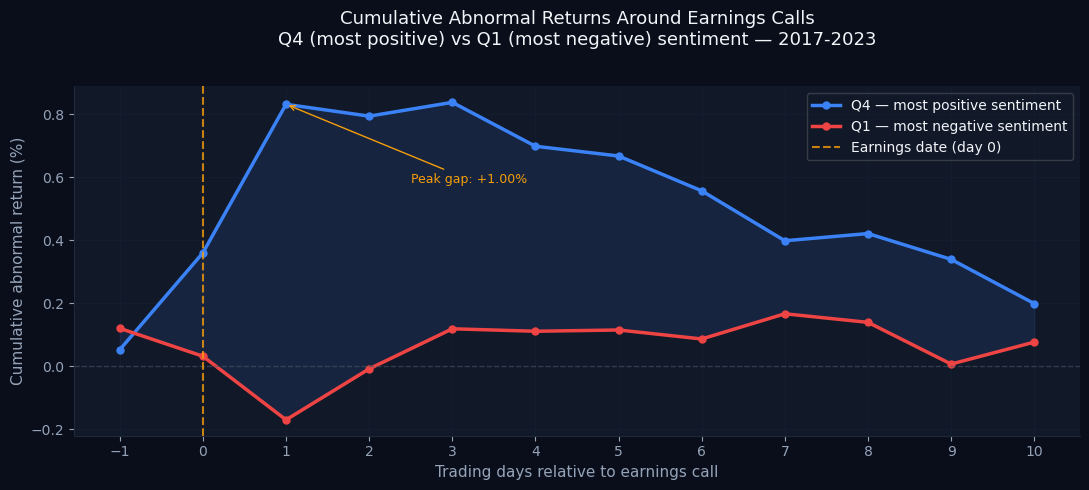

      Saved -> Outputs/event_study/plots/fig1_car_event_time.png


<Figure size 640x480 with 0 Axes>

In [54]:
# ── Figure 1: CAR event-time chart ────────────────────────────
print("Plotting CAR event-time chart (day -1 to +10)...")

day_cols = [f"AR_day_{d}" for d in range(-1, 11)]
q1_daily = ar_df[ar_df["sentiment_quartile"] == "Q1 (most negative)"][day_cols].mean()
q4_daily = ar_df[ar_df["sentiment_quartile"] == "Q4 (most positive)"][day_cols].mean()

q1_car = q1_daily.cumsum().values
q4_car = q4_daily.cumsum().values
days   = list(range(-1, 11))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(days, q4_car * 100, color="#3b82f6", linewidth=2.5,
        marker="o", markersize=5, label="Q4 — most positive sentiment")
ax.plot(days, q1_car * 100, color="#ef4444", linewidth=2.5,
        marker="o", markersize=5, label="Q1 — most negative sentiment")
ax.fill_between(days, q1_car * 100, q4_car * 100,
                alpha=0.12, color="#3b82f6")
ax.axhline(0, color="#475569", linewidth=1, linestyle="--", alpha=0.6)
ax.axvline(0, color="#f59e0b", linewidth=1.5, linestyle="--",
           alpha=0.8, label="Earnings date (day 0)")

ax.set_xlabel("Trading days relative to earnings call", fontsize=11)
ax.set_ylabel("Cumulative abnormal return (%)", fontsize=11)
ax.set_title("Cumulative Abnormal Returns Around Earnings Calls\n"
             "Q4 (most positive) vs Q1 (most negative) sentiment — 2017-2023",
             fontsize=13, pad=30)
ax.set_xticks(days)
ax.legend(fontsize=10, framealpha=0.2)
ax.grid(True, alpha=0.3)

peak_idx  = np.argmax(q4_car - q1_car)
peak_day  = days[peak_idx]
peak_diff = (q4_car - q1_car)[peak_idx] * 100
ax.annotate(f"Peak gap: +{peak_diff:.2f}%",
            xy=(peak_day, q4_car[peak_idx] * 100),
            xytext=(peak_day + 1.5, q4_car[peak_idx] * 100 - 0.25), 
            fontsize=9, color="#f59e0b",
            arrowprops=dict(arrowstyle="->", color="#f59e0b", lw=1))

plt.tight_layout()
plt.show()

plt.savefig("Outputs/event_study/plots/fig1_car_event_time.png", dpi=150, bbox_inches="tight")
print("      Saved -> Outputs/event_study/plots/fig1_car_event_time.png")

- Q4 (most positive sentiment) diverges sharply from Q1 (most negative) starting on earnings day (day 0) and peaks at day 1 — confirming immediate market reaction
- Peak gap between Q4 and Q1 reaches approximately +1.00% by day 1
- Q4 CAR decays gradually from day 1 onward — consistent with initial overreaction followed by partial correction
- Q1 CAR briefly dips negative around day 1 before recovering toward zero — negative sentiment calls produce a short-term drag then stabilise
- By day 10 both lines converge toward zero — the sentiment signal is fully absorbed within approximately 5 trading days
- The pre-announcement period (day -1) shows Q4 already slightly above Q1 — suggesting some information leakage before the call

Plotting sector CAR heatmap...


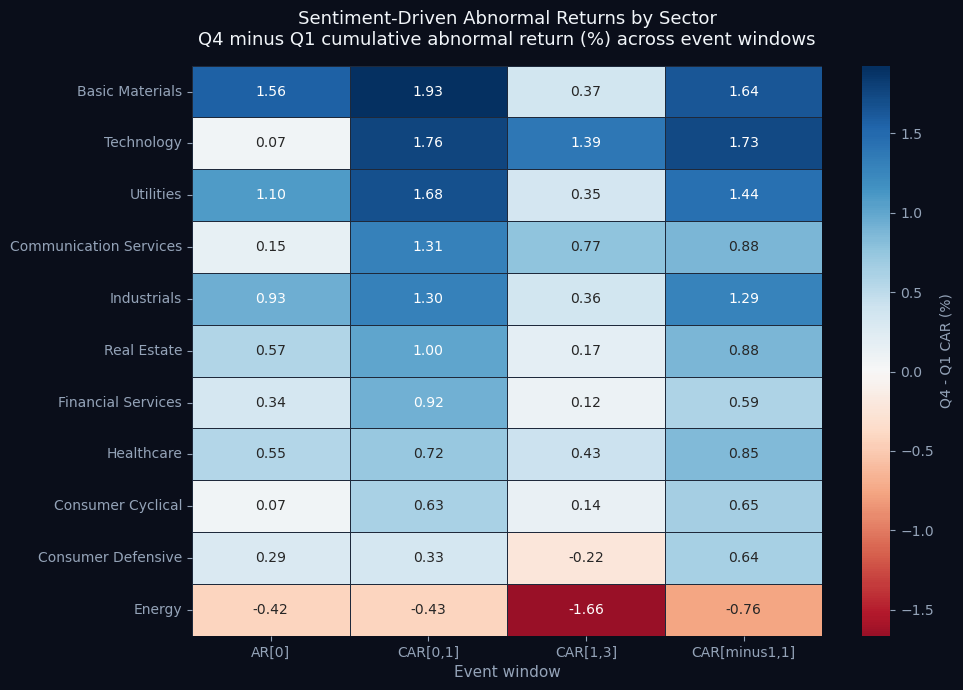

      Saved -> Outputs/event_study/plots/fig2_sector_heatmap.png


<Figure size 640x480 with 0 Axes>

In [57]:
# ── Figure 2: Sector CAR heatmap ──────────────────────────────
print("Plotting sector CAR heatmap...")

sector_car = pd.read_csv("Outputs/event_study/sector_car_summary.csv")
sector_car = sector_car[sector_car["sector"] != "Unknown"].copy()

heatmap_cols   = [c for c in ["diff_AR_0", "diff_CAR_0_1", "diff_CAR_1_3",
                               "diff_CAR_1_5", "diff_CAR_minus1_1"]
                  if c in sector_car.columns]
heatmap_labels = [c.replace("diff_", "").replace("_", "[", 1).replace("_", ",", 1) + "]"
                  for c in heatmap_cols]

heatmap_data = sector_car.set_index("sector")[heatmap_cols].copy()
heatmap_data.columns = heatmap_labels
heatmap_data = heatmap_data.sort_values("CAR[0,1]", ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(
    heatmap_data * 100, ax=ax, cmap="RdBu", center=0,
    annot=True, fmt=".2f", linewidths=0.5, linecolor="#1e293b",
    cbar_kws={"label": "Q4 - Q1 CAR (%)"}, annot_kws={"size": 10}
)
ax.set_title("Sentiment-Driven Abnormal Returns by Sector\n"
             "Q4 minus Q1 cumulative abnormal return (%) across event windows",
             fontsize=13, pad=15)
ax.set_xlabel("Event window", fontsize=11)
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

plt.savefig("Outputs/event_study/plots/fig2_sector_heatmap.png",dpi=150, bbox_inches="tight")
print("      Saved -> Outputs/event_study/plots/fig2_sector_heatmap.png")


- All sectors except Energy show positive Q4 - Q1 differences in CAR[0,1] — sentiment is broadly informative across industries
- Basic Materials (+1.93%) and Technology (+1.76%) show the strongest immediate sentiment effect in CAR[0,1]
- Energy is the clear outlier — negative across all windows, especially CAR[1,3] (-1.66%), consistent with commodity prices dominating over management tone
- CAR[-1,1] column is consistently positive across almost all sectors — pre-announcement sentiment leakage is a broad, cross-sector phenomenon
- Technology sustains its sentiment effect into CAR[1,3] (+1.39%) while most other sectors fade — tech earnings calls contain longer-lasting information
- Consumer Defensive shows the most muted pattern — stable sector where management tone adds little incremental signal


Plotting sentiment surprise vs CAR_0_1 scatter...


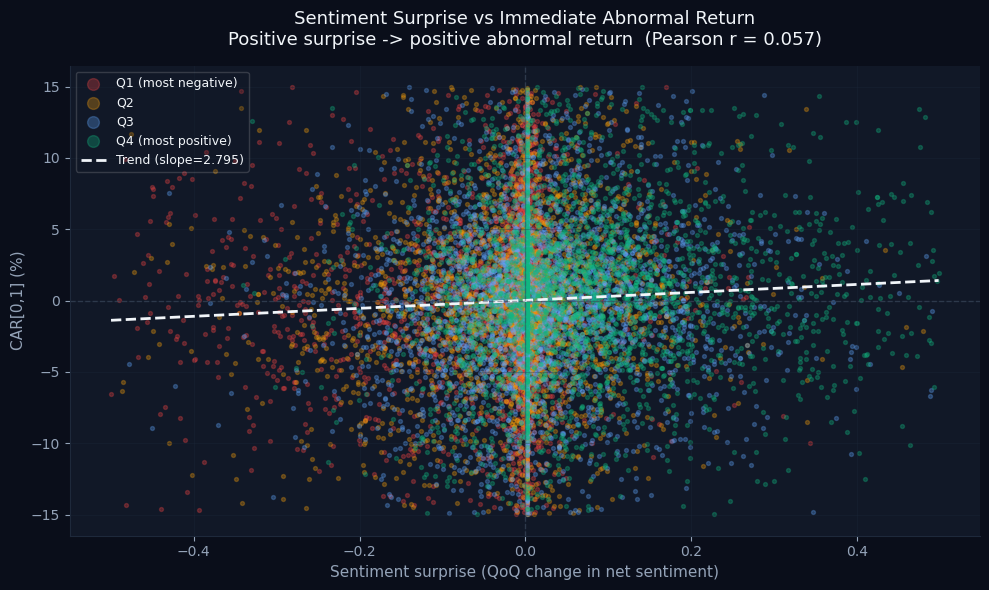

      Saved -> Outputs/event_study/plots/fig3_surprise_vs_car.png


<Figure size 640x480 with 0 Axes>

In [58]:
# ── Figure 3: Sentiment surprise vs CAR scatter ───────────────
print("Plotting sentiment surprise vs CAR_0_1 scatter...")

scatter_df = ar_df[["sentiment_surprise", "CAR_0_1",
                     "sentiment_quartile"]].dropna()
scatter_df = scatter_df[scatter_df["sentiment_surprise"].between(-0.5, 0.5)]
scatter_df = scatter_df[scatter_df["CAR_0_1"].between(-0.15, 0.15)]

# compute and display correlation
corr = scatter_df["sentiment_surprise"].corr(scatter_df["CAR_0_1"])

fig, ax = plt.subplots(figsize=(10, 6))
color_map = {
    "Q1 (most negative)" : "#ef4444",
    "Q2"                 : "#f59e0b",
    "Q3"                 : "#60a5fa",
    "Q4 (most positive)" : "#10b981",
}
for quartile, color in color_map.items():
    subset = scatter_df[scatter_df["sentiment_quartile"] == quartile]
    ax.scatter(subset["sentiment_surprise"], subset["CAR_0_1"] * 100,
               c=color, alpha=0.3, s=8, label=quartile)

z      = np.polyfit(scatter_df["sentiment_surprise"],
                    scatter_df["CAR_0_1"] * 100, 1)
p      = np.poly1d(z)
x_line = np.linspace(scatter_df["sentiment_surprise"].min(),
                     scatter_df["sentiment_surprise"].max(), 100)
ax.plot(x_line, p(x_line), color="#f1f5f9", linewidth=2,
        linestyle="--", label=f"Trend (slope={z[0]:.3f})")

ax.axhline(0, color="#475569", linewidth=1, linestyle="--", alpha=0.5)
ax.axvline(0, color="#475569", linewidth=1, linestyle="--", alpha=0.5)
ax.set_xlabel("Sentiment surprise (QoQ change in net sentiment)", fontsize=11)
ax.set_ylabel("CAR[0,1] (%)", fontsize=11)
ax.set_title(f"Sentiment Surprise vs Immediate Abnormal Return\n"
             f"Positive surprise -> positive abnormal return  "
             f"(Pearson r = {corr:.3f})",
             fontsize=13, pad=15)
ax.legend(fontsize=9, framealpha=0.2, markerscale=3)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.savefig("Outputs/event_study/plots/fig3_surprise_vs_car.png", dpi=150, bbox_inches="tight")
print("      Saved -> Outputs/event_study/plots/fig3_surprise_vs_car.png")

- Pearson r = 0.057 — weak but positive correlation at the individual event level
- Low correlation is expected and healthy — high correlation would imply the market has not yet priced in the signal, which would be inconsistent with semi-strong market efficiency
- Trend line slope = 2.795 — for every 1-unit increase in sentiment surprise, CAR[0,1] increases by approximately 2.8 percentage points on average
- Practical effect: sentiment surprise values typically range ±0.5, implying a realistic CAR range of ±1.4% — consistent with Step 4 findings
- Q4 events (green) cluster in the upper right quadrant — high surprise, high abnormal return
- Q1 events (red) cluster in the lower left — negative surprise, negative return

Plotting AR distribution by sentiment group...


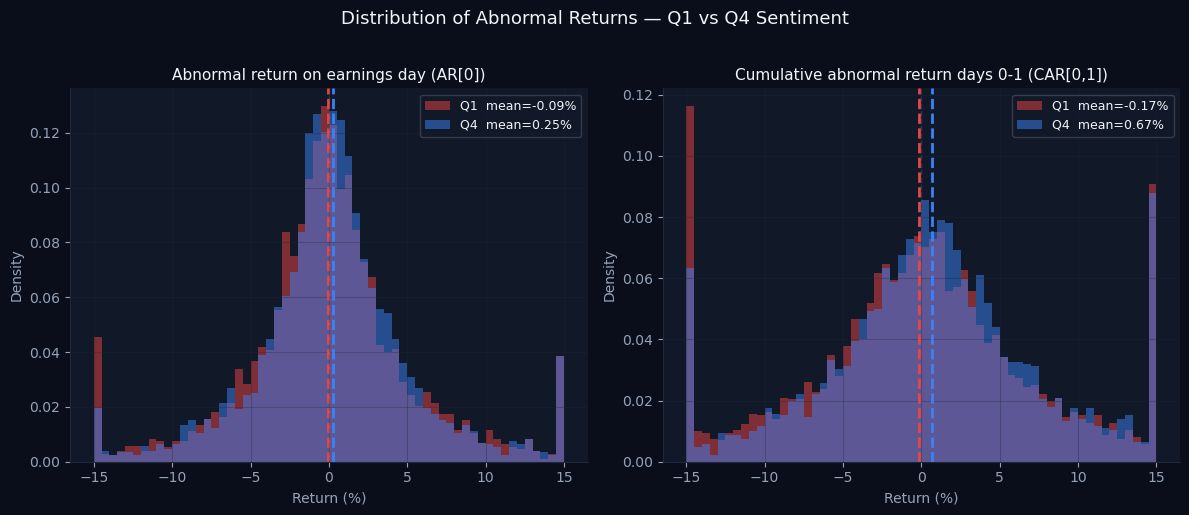

      Saved -> Outputs/event_study/plots/fig4_ar_distribution.png


<Figure size 640x480 with 0 Axes>

In [59]:
# ── Figure 4: AR distribution by sentiment group ──────────────
print("Plotting AR distribution by sentiment group...")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (col, title) in zip(axes, [
    ("AR_0",    "Abnormal return on earnings day (AR[0])"),
    ("CAR_0_1", "Cumulative abnormal return days 0-1 (CAR[0,1])"),
]):
    q1_data = ar_df[ar_df["sentiment_quartile"] == "Q1 (most negative)"][col].dropna()
    q4_data = ar_df[ar_df["sentiment_quartile"] == "Q4 (most positive)"][col].dropna()
    clip    = 0.15
    q1_data = q1_data.clip(-clip, clip)
    q4_data = q4_data.clip(-clip, clip)

    ax.hist(q1_data * 100, bins=60, alpha=0.5, color="#ef4444",
            label=f"Q1  mean={q1_data.mean()*100:.2f}%", density=True)
    ax.hist(q4_data * 100, bins=60, alpha=0.5, color="#3b82f6",
            label=f"Q4  mean={q4_data.mean()*100:.2f}%", density=True)
    ax.axvline(q1_data.mean() * 100, color="#ef4444",
               linewidth=2, linestyle="--")
    ax.axvline(q4_data.mean() * 100, color="#3b82f6",
               linewidth=2, linestyle="--")
    ax.axvline(0, color="#475569", linewidth=1, linestyle="--", alpha=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Return (%)", fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.legend(fontsize=9, framealpha=0.2)
    ax.grid(True, alpha=0.3)

fig.suptitle("Distribution of Abnormal Returns — Q1 vs Q4 Sentiment",
             fontsize=13, y=1.02)

plt.tight_layout()
plt.show()

plt.savefig("Outputs/event_study/plots/fig4_ar_distribution.png", dpi=150, bbox_inches="tight")
print("      Saved -> Outputs/event_study/plots/fig4_ar_distribution.png")

- Both Q1 and Q4 distributions are nearly identical in shape — confirming markets are largely efficient and the signal is subtle, not dominant
- Q4 distribution (blue) is visibly shifted rightward relative to Q1 (red) in both panels — the mean shift is real despite heavy overlap
- AR[0]: Q4 mean = +0.25% vs Q1 mean = -0.09% — small but consistent gap on earnings day itself
- CAR[0,1]: Q4 mean = +0.67% vs Q1 mean = -0.17% — gap widens over two days, showing the market takes a full day to fully process sentiment
- Fat tails on both sides confirm earnings returns are highly variable — some stocks move 10%+ regardless of sentiment tone
- The Q1 spike at -15% in CAR[0,1] reflects a small number of very negative calls with extreme market reactions, pulling the Q1 mean down

Plotting sector significance bar chart...


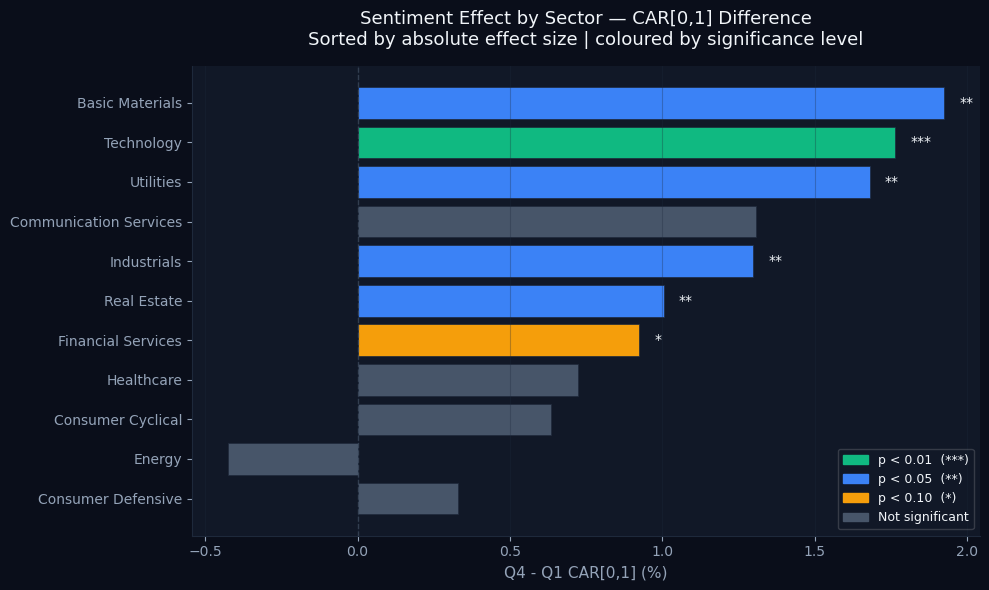

      Saved -> Outputs/event_study/plots/fig5_sector_significance.png


<Figure size 640x480 with 0 Axes>

In [61]:
# ── Figure 5: Sector significance bar chart ───────────────────
print("Plotting sector significance bar chart...")

sector_sig = pd.read_csv("Outputs/event_study/sector_significance.csv")
sector_sig = sector_sig.dropna(subset=["CAR_0_1_diff"]).copy()

# sort by absolute effect size
sector_sig["abs_diff"] = sector_sig["CAR_0_1_diff"].abs()
sector_sig = sector_sig.sort_values("abs_diff", ascending=True)

colors = []
for _, row in sector_sig.iterrows():
    if row["CAR_0_1_sig"] == "***":
        colors.append("#10b981")
    elif row["CAR_0_1_sig"] == "**":
        colors.append("#3b82f6")
    elif row["CAR_0_1_sig"] == "*":
        colors.append("#f59e0b")
    else:
        colors.append("#475569")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(sector_sig["sector"],
               sector_sig["CAR_0_1_diff"] * 100,
               color=colors, edgecolor="#1e293b", linewidth=0.5)

for bar, (_, row) in zip(bars, sector_sig.iterrows()):
    sig_label = row["CAR_0_1_sig"]
    if pd.notna(sig_label) and sig_label != "":
        ax.text(bar.get_width() + 0.05,
                bar.get_y() + bar.get_height() / 2,
                sig_label, va="center",
                fontsize=10, color="#f1f5f9")

ax.axvline(0, color="#475569", linewidth=1, linestyle="--", alpha=0.6)
ax.set_xlabel("Q4 - Q1 CAR[0,1] (%)", fontsize=11)
ax.set_title("Sentiment Effect by Sector — CAR[0,1] Difference\n"
             "Sorted by absolute effect size | coloured by significance level",
             fontsize=13, pad=15)
legend_patches = [
    mpatches.Patch(color="#10b981", label="p < 0.01  (***)"),
    mpatches.Patch(color="#3b82f6", label="p < 0.05  (**)"),
    mpatches.Patch(color="#f59e0b", label="p < 0.10  (*)"),
    mpatches.Patch(color="#475569", label="Not significant"),
]
ax.legend(handles=legend_patches, fontsize=9,
          framealpha=0.2, loc="lower right")
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

plt.savefig("Outputs/event_study/plots/fig5_sector_significance.png", dpi=150, bbox_inches="tight")
print("      Saved -> Outputs/event_study/plots/fig5_sector_significance.png")

Plotting SHAP vs Event Study bridge chart...
      Features in bridge chart: 5
              feature  diff_CAR  mean_shap
4          risk_score -0.002134   0.000951
0       net_sentiment  0.006040   0.002563
3  sentiment_surprise  0.009821   0.002830
1      mgmt_sentiment  0.012096   0.002214
2        qa_sentiment  0.013154   0.005950


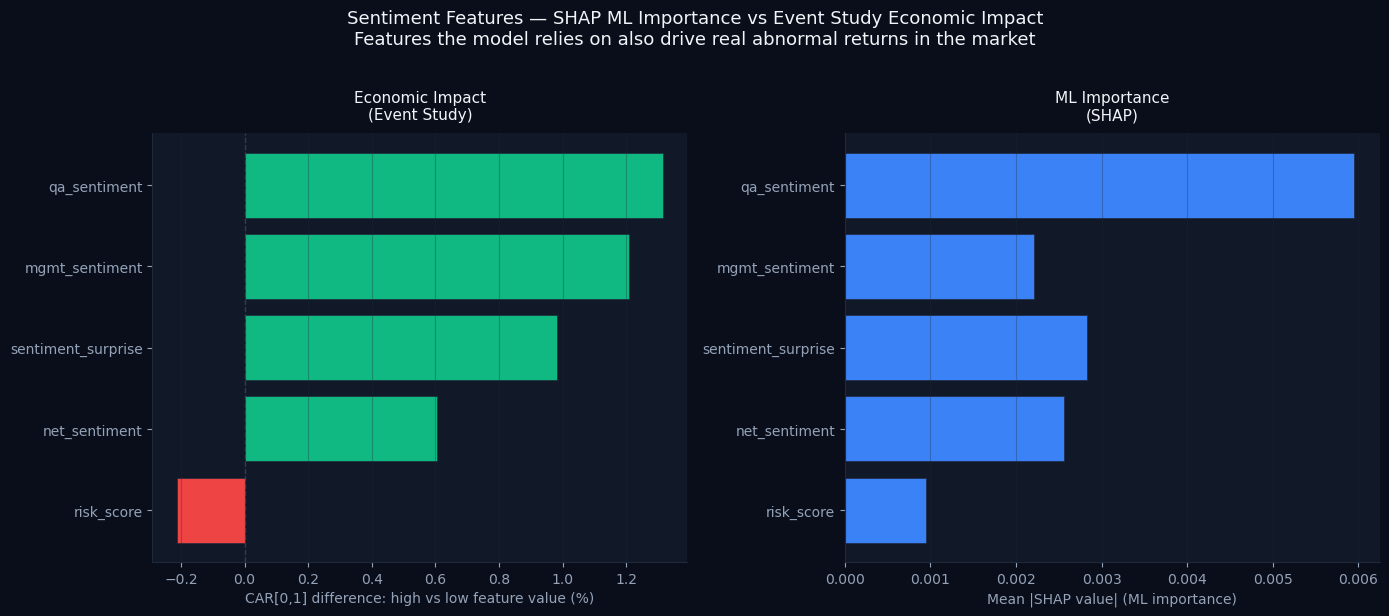

      Saved -> Outputs/event_study/plots/fig6_shap_event_bridge.png


<Figure size 640x480 with 0 Axes>

In [67]:
# ── Figure 6: SHAP vs Event Study bridge ──────────────────────
print("Plotting SHAP vs Event Study bridge chart...")

try:
    # use sentiment-specific SHAP file — all sentiment features ranked
    shap_imp = pd.read_csv("Outputs/shap_explainability/sentiment_feature_importance.csv")

    sentiment_features = [
        "net_sentiment",
        "mgmt_sentiment",
        "qa_sentiment",
        "sentiment_surprise",
        "confidence_score",
        "risk_score",
    ]

    bridge_rows = []
    for feat in sentiment_features:
        if feat not in ar_df.columns:
            continue
        shap_row = shap_imp[shap_imp["feature"] == feat]
        if len(shap_row) == 0:
            continue

        median_val = ar_df[feat].median()
        high_car   = ar_df[ar_df[feat] >  median_val]["CAR_0_1"].mean()
        low_car    = ar_df[ar_df[feat] <= median_val]["CAR_0_1"].mean()
        shap_score = shap_row["mean_shap"].values[0]

        bridge_rows.append({
            "feature"  : feat,
            "high_CAR" : high_car,
            "low_CAR"  : low_car,
            "diff_CAR" : high_car - low_car,
            "mean_shap": shap_score,
        })

    bridge_df = pd.DataFrame(bridge_rows).sort_values("diff_CAR", ascending=True)
    print(f"      Features in bridge chart: {len(bridge_df)}")
    print(bridge_df[["feature", "diff_CAR", "mean_shap"]])

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # left: CAR difference between high and low feature value
    colors_b = ["#10b981" if d > 0 else "#ef4444"
                for d in bridge_df["diff_CAR"]]
    axes[0].barh(bridge_df["feature"],
                 bridge_df["diff_CAR"] * 100,
                 color=colors_b, edgecolor="#1e293b", linewidth=0.5)
    axes[0].axvline(0, color="#475569", linewidth=1,
                    linestyle="--", alpha=0.6)
    axes[0].set_xlabel("CAR[0,1] difference: high vs low feature value (%)",
                       fontsize=10)
    axes[0].set_title("Economic Impact\n(Event Study)", fontsize=11, pad=10)
    axes[0].grid(True, alpha=0.3, axis="x")

    # right: SHAP importance
    axes[1].barh(bridge_df["feature"],
                 bridge_df["mean_shap"],
                 color="#3b82f6", edgecolor="#1e293b", linewidth=0.5)
    axes[1].set_xlabel("Mean |SHAP value| (ML importance)", fontsize=10)
    axes[1].set_title("ML Importance\n(SHAP)", fontsize=11, pad=10)
    axes[1].grid(True, alpha=0.3, axis="x")

    fig.suptitle("Sentiment Features — SHAP ML Importance vs Event Study Economic Impact\n"
                 "Features the model relies on also drive real abnormal returns in the market",
                 fontsize=13, y=1.02)

    plt.tight_layout()
    plt.show()

    plt.savefig("Outputs/event_study/plots/fig6_shap_event_bridge.png", dpi=150, bbox_inches="tight")
    print("      Saved -> Outputs/event_study/plots/fig6_shap_event_bridge.png")

except Exception as e:
    print(f"      Figure 6 skipped: {e}")

- `qa_sentiment` ranks first in both ML importance (SHAP = 0.00595) and economic impact (CAR difference = +1.31%) — the model and the market agree
- The ranking of features by SHAP broadly mirrors their ranking by economic impact — features the model finds important also produce real market effects